In [1]:
import sys
sys.path.append('..')
from common.tools import scipy_simulator, fmu_simulator
import numpy as np

# Using SciPy
inlet_conditions = [0.97, 351.5, 351.6, 150]
true_params = [7E5, 7.2E10]

scipy_simulator(inlet_conditions, true_params)

array([1.07834438e-01, 4.28701704e+02, 4.14992781e+02])

In [2]:
# Using FMU
from pyfmi import load_fmu

model = load_fmu("/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/common/cstr_model.fmu")
opts = model.simulate_options()
opts["result_handling"] = "memory"
opts["CVode_options"]["verbosity"] = 50
opts['CVode_options']['maxh']=0.01

fmu_simulator(inlet_conditions, true_params, model, opts)

array([1.07831731e-01, 4.28696634e+02, 4.15091346e+02])

In [3]:
# Running simulations for a range of different parameters

def run_multiple_times(simulator, n_iter=100):
    
    store = []
    for it in range(n_iter):
        
        params = np.random.rand(2)*10
        params[0] = params[0]*1E5
        params[1] = params[1]*1E10
        try:
            res = simulator(params)
            store.append([params,res])
        except RuntimeError:
            continue
        
    return store

In [4]:
import matplotlib.pyplot as plt
from scipy import stats


def plot_results(store):
    plt.subplots(1,3,figsize=(15,5))
    x = [item[0][0] for item in store]
    y = [item[0][1] for item in store]
    z1 = [item[1][0] for item in store]
    z2 = [item[1][1] for item in store]
    z3 = [item[1][2] for item in store]
    

    # Plot histogram of variable 1
    plt.subplot(1,3,1)
    plt.scatter(x, y,
           linewidths=1, alpha=.7,
           edgecolor='k',
           c=z1)
    plt.colorbar()
    plt.scatter(true_params[0], true_params[1],c='r',marker='s')
    plt.title('C')
    plt.xlabel('UA')
    plt.ylabel('k_0')
    
    # Plot histogram of variable 2
    plt.subplot(1,3,2)
    plt.scatter(x, y,
           linewidths=1, alpha=.7,
           edgecolor='k',
           c=z2)
    plt.colorbar()
    plt.scatter(true_params[0], true_params[1],c='r',marker='s')
    plt.title('T')
    plt.xlabel('UA')
    plt.ylabel('k_0')
    

    # Plot histogram of variable 2
    plt.subplot(1,3,3)
    plt.scatter(x, y,
           linewidths=1, alpha=.7,
           edgecolor='k',
           c=z3)
    plt.colorbar()
    plt.scatter(true_params[0], true_params[1],c='r',marker='s')
    plt.title('T_c')
    plt.xlabel('UA')
    plt.ylabel('k_0')
    




In [9]:
%%timeit
from functools import partial

simulator = partial(scipy_simulator,inlet_conditions)

store = run_multiple_times(simulator,n_iter=1000)

../common/tools.py:128: RuntimeWarning: Solution not converged. [1.30146712 0.07538665 0.03739586]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [1.39048764 0.05971231 0.05939313]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [1.13089617 0.0475244  0.10491322]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [3.39347630e+00 2.37133621e-02 1.81639588e-03]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [1.1302329  0.03361782 0.13110323]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [1.1990804  0.04258708 0.01227183]
  warnings.warn(f'Solution not con

../common/tools.py:128: RuntimeWarning: Solution not converged. [1.62975474 0.05339892 0.01009819]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [1.12361034 0.04059057 0.00591564]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [1.4664435  0.05529383 0.01170156]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [1.34680848 0.05032522 0.01662616]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [1.63918518 0.08297753 0.05747299]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [10.88897259  0.39740386  0.3215363 ]
  warnings.warn(f'Solution not converged. {

1min ± 1 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [10]:
from functools import partial

simulator = partial(scipy_simulator,inlet_conditions)

store = run_multiple_times(simulator,n_iter=1000)

../common/tools.py:128: RuntimeWarning: Solution not converged. [1.18930477 0.06086493 0.03641911]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [8.97461099 0.29155827 0.38115286]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [1.94816665 0.00532528 0.07123458]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [4.29544243 0.0834314  0.21128177]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)


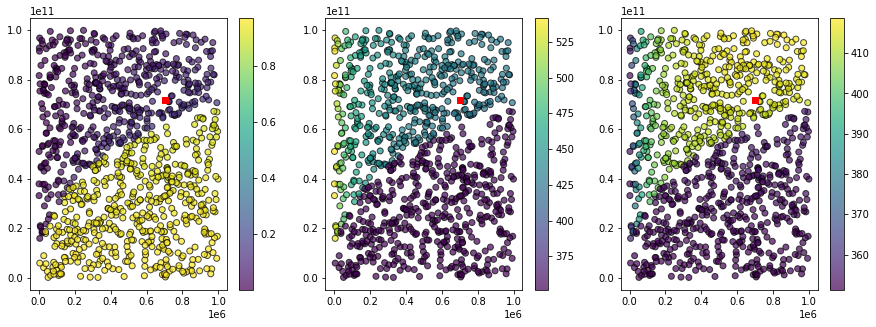

In [54]:
plot_results(store)

In [5]:
%%timeit
def simulator(params):
    return fmu_simulator(inlet_conditions, params, model,opts=opts)

store = run_multiple_times(simulator,n_iter=1000)

../common/tools.py:128: RuntimeWarning: Solution not converged. [1.8591519  0.12156887 0.10471598]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [2.19725922 0.07988884 0.07202248]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [3.50285666 0.01540597 0.01948442]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [12.21263146  0.46744155  0.40549615]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [2.31729472 0.09150618 0.08019968]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [9.77418247 0.40729897 0.35039056]
  warnings.warn(f'Solution not converged. {

../common/tools.py:128: RuntimeWarning: Solution not converged. [9.25716488 0.44786913 0.38318836]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [9.63088    0.27863162 0.24821329]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [8.09667595 0.30159794 0.25440375]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [5.26953836 0.10019909 0.09296436]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [4.20951112 0.0871289  0.07519087]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [9.82142115 0.19919986 0.17603605]
  warnings.warn(f'Solution not converged. {rel

20 s ± 1.96 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [7]:
def simulator(params):
    return fmu_simulator(inlet_conditions, params, model,opts=opts)

store = run_multiple_times(simulator,n_iter=1000)
store

../common/tools.py:128: RuntimeWarning: Solution not converged. [11.12254212  0.26898255  0.24233395]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [1.19864497 0.11806868 0.1019234 ]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [8.99441571 0.27229071 0.23863323]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [2.44515258 0.11480011 0.09976544]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
../common/tools.py:128: RuntimeWarning: Solution not converged. [1.64686615 0.00539994 0.00774576]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)


[[array([9.26057498e+04, 9.57950379e+10]),
  array([9.86416494e-03, 4.73646867e+02, 3.98186866e+02])],
 [array([7.31853702e+05, 9.21414882e+10]),
  array([7.64003507e-02, 4.31168560e+02, 4.17634247e+02])],
 [array([3.62339709e+05, 4.61453580e+10]),
  array([  0.93147388, 355.29013786, 354.20975917])],
 [array([6.64608504e+05, 5.07550149e+09]),
  array([  0.9666577 , 351.8555007 , 351.80845342])],
 [array([3.21612089e+05, 2.37613600e+10]),
  array([  0.95274372, 353.25650787, 352.72964221])],
 [array([2.62632877e+05, 8.14537266e+10]),
  array([4.01806371e-02, 4.46684599e+02, 4.12119516e+02])],
 [array([5.02102475e+05, 9.14134385e+10]),
  array([6.08016335e-02, 4.35935434e+02, 4.16536159e+02])],
 [array([9.21956991e+05, 3.03243905e+10]),
  array([  0.94764993, 353.50810523, 353.24110214])],
 [array([8.86538671e+05, 1.34918095e+10]),
  array([  0.96080367, 352.36173726, 352.25150441])],
 [array([7.15758989e+05, 9.47740388e+10]),
  array([7.25816279e-02, 4.31677978e+02, 4.17803797e+02])],


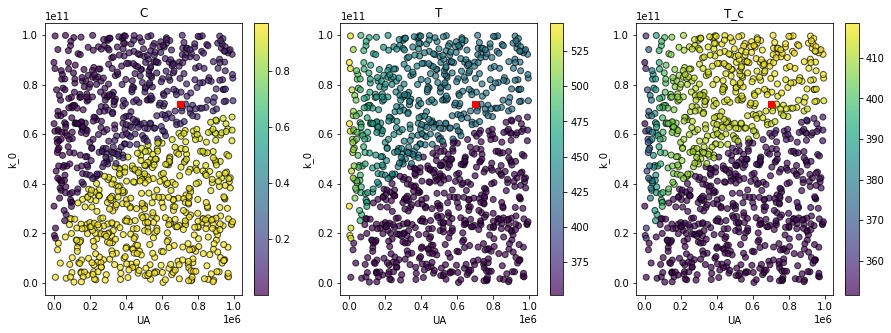

In [8]:
plot_results(store)